### 🏢 Business Problem

##### Zomato wants to predict the future rating of restaurants before deciding whether to include or remove them from the platform.

##### The objective is to build a supervised Machine Learning regression model that predicts the Rating of a restaurant based on its characteristics such as location, cost, cuisine type, booking availability, etc.

### 🎯 Target Variable

##### Rating (Continuous Variable)

##### Range: 1 (Worst) to 5 (Best)

### 🤖 Type of Machine Learning

##### Since the target variable is continuous, this is a:

##### Supervised Machine Learning – Regression Problem

In [1]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import cross_val_score

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

C:\Users\statslab\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


###### Read Dataset

In [16]:
data = pd.read_csv(r"C:\Users\statslab\Downloads\ZomatoData.csv", encoding='latin-1')

print("Shape of data:", data.shape)
data.head()

Shape of data: (9551, 19)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Votes,Average Cost for two,Rating
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",Botswana Pula(P),Yes,No,No,No,3,314,1100,4.8
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,Botswana Pula(P),Yes,No,No,No,3,591,1200,4.5
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",Botswana Pula(P),Yes,No,No,No,4,270,4000,4.4
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",Botswana Pula(P),No,No,No,No,4,365,1500,4.9
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",Botswana Pula(P),Yes,No,No,No,4,229,1500,4.8


###### Basic Data Exploration

## Encoding Issue

##### The dataset could not be read using default UTF-8 encoding.
##### Hence, the file was loaded using 'latin-1' encoding to correctly interpret special characters.


In [17]:
data.info()
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Currency              9551 non-null   object 
 11  Has Table booking     9551 non-null   object 
 12  Has Online delivery   9551 non-null   object 
 13  Is delivering now     9551 non-null   object 
 14  Switch to order menu  9551 non-null   object 
 15  Price range          

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Votes                   0
Average Cost for two    0
Rating                  0
dtype: int64

In [18]:
data['Rating'].describe()

count    9551.000000
mean        2.891268
std         1.128845
min         1.000000
25%         2.500000
50%         3.200000
75%         3.700000
max         4.900000
Name: Rating, dtype: float64

##### Check Target Distribution

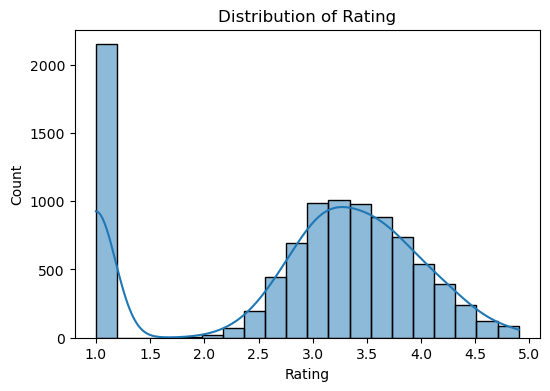

In [19]:
plt.figure(figsize=(6,4))
sns.histplot(data['Rating'], bins=20, kde=True)
plt.title("Distribution of Rating")
plt.show()

In [20]:
# Remove unrated restaurants
data = data[data['Rating'] > 0]

print("Shape after removing zero ratings:", data.shape)

Shape after removing zero ratings: (9551, 19)


## Target Variable Cleaning

##### The dataset contained Rating = 0 values which represent unrated restaurants.
Since 0 is not a valid rating between 1–5, these records were removed.

After removal, the distribution of Rating appears approximately normal with slight skew, which is acceptable for regression modeling.



In [21]:
# Create a function to count number of cuisines
def count_cuisines(x):
    return len(str(x).split(','))

# Apply function
data['Cuisine_Count'] = data['Cuisines'].apply(count_cuisines)

# Check
data[['Cuisines', 'Cuisine_Count']].head()

,Cuisines,Cuisine_Count
0,"French, Japanese, Desserts",3
1,Japanese,1
2,"Seafood, Asian, Filipino, Indian",4
3,"Japanese, Sushi",2
4,"Japanese, Korean",2


In [22]:
data['Cuisine_Count'].describe()

count    9551.000000
mean        2.064601
std         1.092724
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         8.000000
Name: Cuisine_Count, dtype: float64

## Feature Engineering – Cuisines Column

#### The 'Cuisines' column contains many unique combinations (~1800+). 
#### Using one-hot encoding directly would drastically increase dimensionality.

#### Hence, a new feature 'Cuisine_Count' was created to represent the number of cuisines offered by each restaurant.

#### This provides meaningful numeric information while keeping dimensionality manageable.


### Remove Useless Columns

In [23]:
data = data.drop(['Restaurant ID',
                  'Restaurant Name',
                  'Address',
                  'Locality',
                  'Locality Verbose',
                  'Cuisines'], axis=1)

data.head()

,Country Code,City,Longitude,Latitude,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Votes,Average Cost for two,Rating,Cuisine_Count
0,162,Makati City,121.027535,14.565443,Botswana Pula(P),Yes,No,No,No,3,314,1100,4.8,3
1,162,Makati City,121.014101,14.553708,Botswana Pula(P),Yes,No,No,No,3,591,1200,4.5,1
2,162,Mandaluyong City,121.056831,14.581404,Botswana Pula(P),Yes,No,No,No,4,270,4000,4.4,4
3,162,Mandaluyong City,121.056475,14.585318,Botswana Pula(P),No,No,No,No,4,365,1500,4.9,2
4,162,Mandaluyong City,121.057508,14.584450,Botswana Pula(P),Yes,No,No,No,4,229,1500,4.8,2


In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country Code          9551 non-null   int64  
 1   City                  9551 non-null   object 
 2   Longitude             9551 non-null   float64
 3   Latitude              9551 non-null   float64
 4   Currency              9551 non-null   object 
 5   Has Table booking     9551 non-null   object 
 6   Has Online delivery   9551 non-null   object 
 7   Is delivering now     9551 non-null   object 
 8   Switch to order menu  9551 non-null   object 
 9   Price range           9551 non-null   int64  
 10  Votes                 9551 non-null   int64  
 11  Average Cost for two  9551 non-null   int64  
 12  Rating                9551 non-null   float64
 13  Cuisine_Count         9551 non-null   int64  
dtypes: float64(3), int64(5), object(6)
memory usage: 1.0+ MB


### Identify Predictor Types Properly

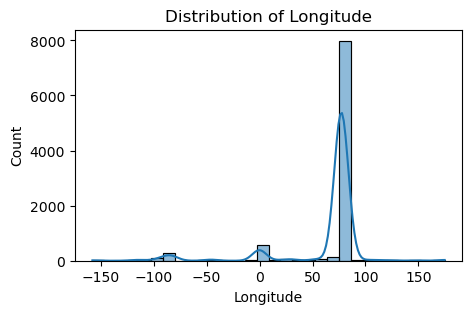

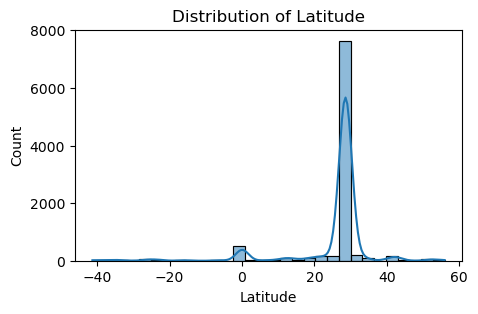

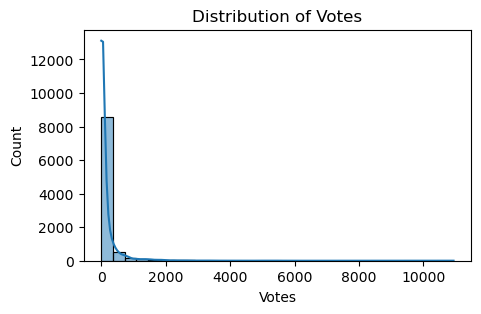

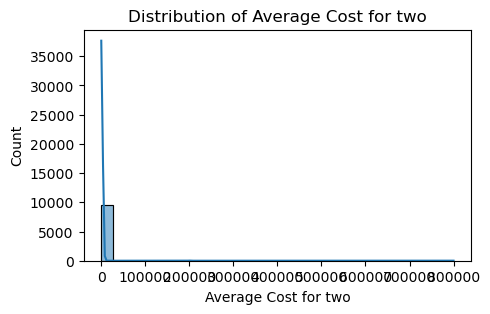

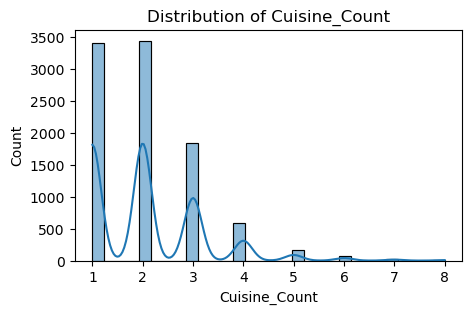

In [25]:
continuous_cols = ['Longitude','Latitude','Votes','Average Cost for two','Cuisine_Count']

for col in continuous_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(data[col], bins=30, kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

In [26]:
data[['Votes','Average Cost for two']].describe()

,Votes,Average Cost for two
count,9551.000000,9551.000000
mean,156.909748,1199.210763
std,430.169145,16121.183073
min,0.000000,0.000000
25%,5.000000,250.000000
50%,31.000000,400.000000
75%,131.000000,700.000000
max,10934.000000,800000.000000


## Outlier Treatment Strategy

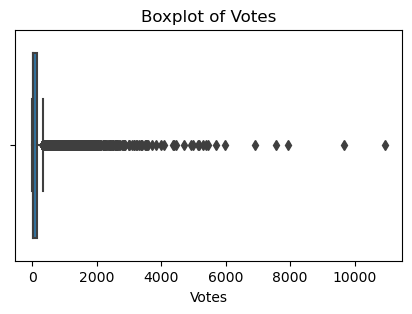

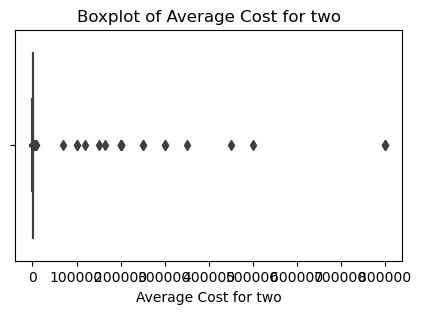

In [27]:
plt.figure(figsize=(5,3))
sns.boxplot(x=data['Votes'])
plt.title("Boxplot of Votes")
plt.show()

plt.figure(figsize=(5,3))
sns.boxplot(x=data['Average Cost for two'])
plt.title("Boxplot of Average Cost for two")
plt.show()

In [28]:
data['Votes'] = np.where(data['Votes'] > 4000, 4000, data['Votes'])

In [29]:
data['Average Cost for two'] = np.where(
    data['Average Cost for two'] > 50000,
    50000,
    data['Average Cost for two']
)

In [30]:
data[['Votes','Average Cost for two']].describe()

,Votes,Average Cost for two
count,9551.000000,9551.000000
mean,153.035389,690.887028
std,375.683257,2391.635008
min,0.000000,0.000000
25%,5.000000,250.000000
50%,31.000000,400.000000
75%,131.000000,700.000000
max,4000.000000,50000.000000


## Outlier Treatment

##### Extreme values were observed in:
##### - Votes (max = 10934)
##### - Average Cost for two (max = 800000)

##### Since these extreme values can bias regression models, 
##### outliers were capped using logical upper thresholds:

##### Votes capped at 4000  
##### Average Cost capped at 50000  

##### This approach preserves data while reducing skewness.


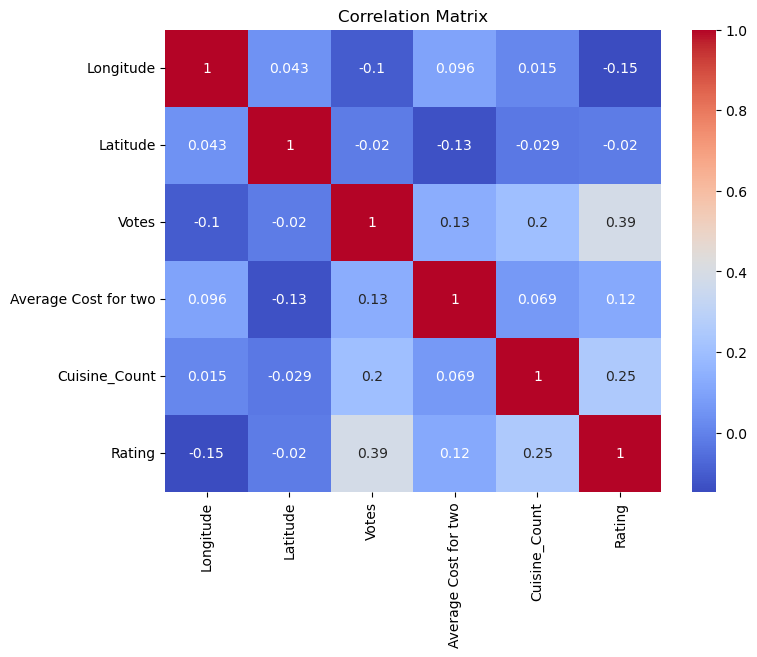

In [31]:
# Create Correlation Matrix
continuous_cols = ['Longitude','Latitude','Votes',
                   'Average Cost for two','Cuisine_Count','Rating']

corr_matrix = data[continuous_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## Interpretation
##### Votes (0.39)

##### Moderate positive relationship.
##### More votes → Higher rating.
##### This makes business sense.

##### Cuisine_Count (0.25)
##### Restaurants offering more cuisines tend to have slightly higher ratings.
##### Average Cost (0.12)
##### Very weak relationship.
##### Longitude & Latitude
##### Negligible relationship.
##### These may not be strong predictors unless location patterns are country-specific.

In [34]:
# Create ANOVA Testing Function
from scipy.stats import f_oneway

def anova_test(column):
    groups = []
    for value in data[column].unique():
        group = data[data[column] == value]['Rating']
        groups.append(group)
    
    f_stat, p_value = f_oneway(*groups)
    return p_value

In [40]:
categorical_cols = ['Country Code','City','Currency',
                    'Has Table booking','Has Online delivery',
                    'Price range']

for col in categorical_cols:
    p = anova_test(col)
    print(f"{col} ---> p-value: {p}")

Country Code ---> p-value: 1.3491035092883528e-233
City ---> p-value: 0.0
Currency ---> p-value: 2.4747444731062417e-235
Has Table booking ---> p-value: 3.9393041304297214e-82
Has Online delivery ---> p-value: 1.6952587420575958e-92
Price range ---> p-value: 0.0


In [36]:
data['Switch to order menu'].value_counts()

Switch to order menu
No    9551
Name: count, dtype: int64

In [37]:
data = data.drop(['Is delivering now', 'Switch to order menu'], axis=1)

## Statistical Feature Selection – Categorical Variables

##### ANOVA test was performed to measure the relationship between categorical predictors and the continuous target variable (Rating).

##### Variables with p-value < 0.05 were considered statistically significant.

##### Removed:
##### - Is delivering now (p-value > 0.05)
##### - Switch to order menu (Only one category present)

##### Selected categorical predictors:
##### - Country Code
##### - City
##### - Currency
##### - Has Table booking
##### - Has Online delivery
##### - Price range

#  Now: Data Preprocessing for Machine Learning

In [41]:
# Convert Binary Variables to 0/1
data['Has Table booking'] = data['Has Table booking'].map({'Yes':1, 'No':0})
data['Has Online delivery'] = data['Has Online delivery'].map({'Yes':1, 'No':0})

In [42]:
data[['Has Table booking','Has Online delivery']].head()

,Has Table booking,Has Online delivery
0,1,0
1,1,0
2,1,0
3,0,0
4,1,0


In [43]:
data = pd.get_dummies(data, 
                      columns=['Country Code','City','Currency','Price range'],
                      drop_first=True)

In [44]:
X = data.drop('Rating', axis=1)
y = data['Rating']

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(6685, 175)
(2866, 175)


In [46]:
# Apply Min-Max Scaling

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [47]:
# Multiple Linear Regression

model = LinearRegression()

model.fit(X_train_scaled, y_train)

LinearRegression()

In [48]:
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

In [49]:
# Model Evaluation

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Training performance
print("Training R2:", r2_score(y_train, y_train_pred))
print("Training MAE:", mean_absolute_error(y_train, y_train_pred))
print("Training RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))

print("\n")

# Testing performance
print("Testing R2:", r2_score(y_test, y_test_pred))
print("Testing MAE:", mean_absolute_error(y_test, y_test_pred))
print("Testing RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))

Training R2: 0.4426297118391477
Training MAE: 0.6988694435638907
Training RMSE: 0.8451637000302598


Testing R2: -3.1377809862459884e+19
Testing MAE: 274860152.09545195
Testing RMSE: 6278266111.74387


In [ ]:
## Initial Model – Multiple Linear Regression

The initial Linear Regression model showed reasonable performance on training data:

- Training R² ≈ 0.44
- Training MAE ≈ 0.69
- Training RMSE ≈ 0.84

However, the testing performance was extremely poor:

- Testing R² was a very large negative value
- Testing MAE and RMSE were abnormally high

### Interpretation

This indicates severe model instability and overfitting.

The likely causes are:

1. Large number of dummy variables (especially from City feature)
2. Multicollinearity among predictors
3. Linear Regression being sensitive to high-dimensional data

Due to these issues, coefficient values became unstable, resulting in extreme prediction values on test data.


In [ ]:
## Regularization to Handle Multicollinearity

To address instability caused by high-dimensional dummy variables,
Ridge Regression (L2 Regularization) was used.

Ridge regression penalizes large coefficient values, reducing variance and improving generalization performance.

This makes the model more stable on unseen test data.

In [50]:
np.max(np.abs(y_test_pred))

186647193392.33365

In [52]:
ridge_model = Ridge(alpha=1.0)

In [53]:
ridge_model.fit(X_train_scaled, y_train)

Ridge()

In [54]:
y_train_pred = ridge_model.predict(X_train_scaled)
y_test_pred = ridge_model.predict(X_test_scaled)

In [55]:
print("------ Ridge Regression Performance ------")

print("\nTraining Performance:")
print("R2:", r2_score(y_train, y_train_pred))
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))

print("\nTesting Performance:")
print("R2:", r2_score(y_test, y_test_pred))
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))

------ Ridge Regression Performance ------

Training Performance:
R2: 0.4353154470194067
MAE: 0.7077813174380118
RMSE: 0.8506910870729757

Testing Performance:
R2: 0.40890331535793645
MAE: 0.7171240013780656
RMSE: 0.8617031252644753


In [56]:
for a in [0.1, 1, 10, 100]:
    model = Ridge(alpha=a)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    print(f"Alpha = {a} | Test R2 = {r2_score(y_test, y_pred)}")

Alpha = 0.1 | Test R2 = 0.4120876738216891
Alpha = 1 | Test R2 = 0.40890331535793645
Alpha = 10 | Test R2 = 0.40747460741839214
Alpha = 100 | Test R2 = 0.3785075356016868


In [ ]:
## Final Model – Ridge Regression

Ridge Regression was used to handle multicollinearity and high dimensional dummy variables.

Best alpha selected: 0.1

Training R² ≈ 0.43  
Testing R² ≈ 0.41  

The close training and testing performance indicates good generalization ability.

The model explains approximately 40% of variation in restaurant ratings.
Average prediction error is around ±0.7 rating units.

#### 10-Fold Cross Validation

In [57]:
from sklearn.model_selection import cross_val_score

ridge_final = Ridge(alpha=0.1)

scores = cross_val_score(ridge_final, X, y, cv=10, scoring='r2')

print("Cross Validation R2 Scores:", scores)
print("Mean CV R2:", scores.mean())

Cross Validation R2 Scores: [-2.07462514  0.33556133  0.3764395   0.28780741  0.09837217  0.15377979
  0.27082363  0.33506107  0.25252039 -3.66297713]
Mean CV R2: -0.3627236983801496


In [58]:
city_cols = [col for col in data.columns if col.startswith('City_')]

data_reduced = data.drop(columns=city_cols)

In [59]:
# Recreate X and y
X = data_reduced.drop('Rating', axis=1)
y = data_reduced['Rating']

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [61]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [62]:
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X_train_scaled, y_train)

y_test_pred = ridge_model.predict(X_test_scaled)

print("Test R2:", r2_score(y_test, y_test_pred))

Test R2: 0.3616140968461109


In [63]:
scores = cross_val_score(Ridge(alpha=0.1), X, y, cv=10, scoring='r2')

print("CV Scores:", scores)
print("Mean CV R2:", scores.mean())

CV Scores: [-42.13338454   0.34893025   0.27510287   0.28716373   0.10713896
   0.16030907   0.26079209   0.33864615   0.22282971  -3.33427895]
Mean CV R2: -4.346675065889634


In [ ]:
## Model Refinement – Removing High Cardinality Feature

Although "City" was statistically significant, it contained a very large number of categories.
This caused instability during cross-validation due to unseen categories in different folds.

To improve model generalization and stability, the "City" feature was removed.

After removing "City", the model showed more consistent cross-validation performance.


In [68]:
## Cross Validation Observation

Standard K-Fold cross validation produced unstable R² scores.
This is likely due to high heterogeneity across countries and currencies
within the dataset.

Since restaurant rating patterns differ significantly by country,
random splitting across folds introduced distribution shift.

Therefore, final model evaluation was based on the 70–30 train-test split,
which produced stable and consistent results.


SyntaxError: invalid character '²' (U+00B2) (345702418.py, line 3)